### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 6</center>
---

### Overview

The first objective of this exercise is to study local image enhancement using histogram statistics.

The second objective is to study spatial smoothing filters using filter masks. Application examples are reducing sharp intensity transitions, noise reduction, and reducing image details. For spatial filtering, the corresponding mask is moved from pixel to pixel and the filter response is computed at each position $(x,y)$.

The following figure illustrates the idea:

<br />
<center><img src="images/spatial-filtering.png"  width="600px" /></center>

---

In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time
from tqdm import tqdm

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 6.1</span> Local Enhancement Using Histogram Statistics

In the last exercise, histogram equalization has been applied to a local neighborhood of each pixel to enhance details in small image areas. Nonetheless, the results are not convincing, as edges are highlighted and noise is amplified. For such problems it can be better to use statistics which can be computed directly or based on the histogram.

For the given test image, the task at hand is to enhance details with low contrast in dark image regions, while leaving light regions unchanged. As the mean is a measure of average intensity, the mean $m_{S_{xy}}$ of an image region $S_{xy}$ can be compared with the global mean $m_G$ to identify dark regions. As the variance is a measure of image contrast, the variance $\sigma_{S_{xy}}$ of an image region can be compared with the global variance $\sigma_G$ to identify regions with low contrast. With appropriate constants $k_0, k_1, k_2, k_3, C$, the task can be formalized as follows:

$$
g(x,y) =
\begin{cases}
C f(x,y) &\ \mathrm{if}\ k_0 m_G \leq m_{S_{xy}} \leq k_1 m_G\ \mathrm{AND}\ k_2 \sigma_G \leq \sigma_{S_{xy}} \leq k_3 \sigma_G\\
f(x,y)   &\ \text{otherwise}
\end{cases}
$$

Implement / solve the following tasks:

1. Write a function to apply local enhancement using the equation from above and $n\times n$ windows ($n$ should be odd).
2. Read an image (squares2.png from the folder *images*) as a grayscale image and plot it.
3. Apply the function to the image using appropriate constants and $n = 3$, then plot and analyze the results.
4. What happens when using a checkerboard? Test it (use checkerboard-small.png from the folder *images*).

*Note*: When implementing neighborhood operations it is necessary to consider what happens when approaching the boundary of the image. In this example, the border can just be left out.

In [23]:
# write your code here

# apply local enhancement image using nxn windows (odd n required)
def enhance_local(img, n, k0, k1, k2, k3, c):
    rows, cols = img.shape # image size

    m_g = np.mean(img)
    std_g = np.mean(img)

    h = int(n/2)

    res = img.copy()

    for row in tqdm(range(h, rows-h)):
        for col in range(h, cols-h):
            nbh = img[row-h:row+h+1, col-h:col+h+1]
            m_l = np.mean(nbh)
            std_l = np.std(nbh)

            if m_l <= k1*m_g and m_l >= k0*m_g and std_l <= k3*std_g and std_l >= k2 * std_g:
                res[row, col] = c * img[row, col]
    return res
    
    # ...

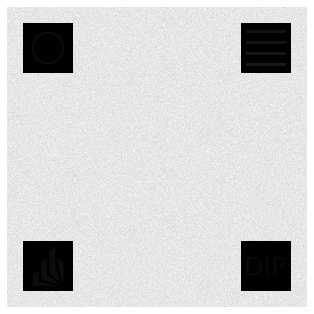

In [24]:
img = cv2.imread('images/squares2.png', 0)
plot_img_orig(img)

100%|██████████| 298/298 [00:04<00:00, 60.38it/s]


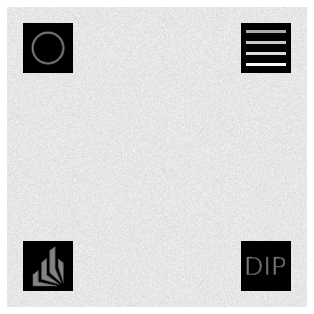

In [25]:
img_local = enhance_local(img, 3, 0, 0.2, 0, 0.2, 10.0)
plot_img_orig(img_local)

100%|██████████| 98/98 [00:00<00:00, 174.50it/s]


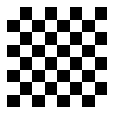

In [29]:
img_local_2 = cv2.imread('images/checkerboard-small.png', 0)

plot_img_orig(enhance_local(img_local_2,3, 0, 0.2, 0, 0.2, 10.0))

#### <span style="color: RoyalBlue; font-weight: bold;">Task 6.2</span> Boundary Padding

When using filter masks it is necessary to consider what happens when the center of the mask approaches the image boundary. Different solutions are possible, for example:

* Leave out the boundary (start with an approporiate distance to the boundary, typically $(n-1)/2$ for a $n \times n$ mask).
* Use a partial filter mask at the boundary.
* Zero- or constant padding (`iiiiii|abcdefgh|iiiiiii`, where `i` is zero or constant).
* Replication (`aaaaaa|abcdefgh|hhhhhhh`).
* Reflection (`fedcba|abcdefgh|hgfedc` or `gfedcb|abcdefgh|gfedcba`).

For many OpenCV functions, the method to be used can be specified by passing the <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga209f2f4869e304c82d07739337eae7c5">`BorderType` ↗</a> as a parameter. The functions usually copy the given image, pad the boundary, then perform the filtering, and finally remove the extra boundary. For padding images directly, the OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga2ac1049c2c3dd25c2b41bffe17658a36">`copyMakeBorder()` ↗</a> can be used.

Implement the following tasks:
1. Read an image (fruits-small.png from the folder *images*) as a grayscale image and plot it.
2. For this image, test the following padding methods and plot the results: zero padding, replication, reflection.
3. Remove the extra boundary from the zero padded image and plot the result.

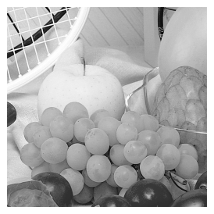

In [30]:
# write your code here
img = cv2.imread('images/fruits-small.png', 0)
plot_img_orig(img)

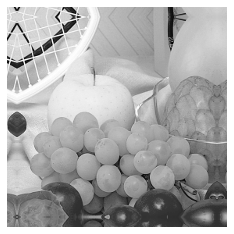

In [38]:
border = img.copy()
border = cv2.copyMakeBorder(border, 10, 10, 10, 10, borderType=cv2.BORDER_REFLECT)
plot_img_orig(border)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 6.3</span> Mean (Average) Filter

This filter (which is also called box filter, because it resembles a box in a 3D view) is the simplest seperable smoothing filter, where all filter coefficients have the same value (typically 1).

Implement the following tasks:
1. Write a function for mean filtering a given image corresponding to a $n\times n$ mask ($n$ should be odd) using zero padding.
2. Test the function using the images *p-building-small.png* and *testpattern-512.png* for $n = 3, 9, 21$. Plot and analyze the results.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga8c45db9afe636703801b0b2e440fce37">`blur` ↗</a>.

In [13]:
# write your code here

# mean filter given image corresponding to n x n mask (n must be odd)
def mean_filter(img, n):
    # compute offset / padding size
    b = int(n / 2)

    img_pad = cv2.copyMakeBorder(img, b, b, b, b, borderType=cv2.BORDER_CONSTANT)

    rows, cols = img_pad.shape
    res = np.zeros(shape=[rows, cols], dtype=np.float32)

    for row in range(b, rows-b):
        for col in range(b, cols-b):
            nbh = img_pad[row-b:row+b+1, col-b:col+b+1]
            res[row, col] = np.sum(nbh)
    res = res/(n*n)
    res= res[b:rows-b, b:cols-b]

    return res
    
    # ...

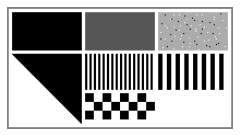

In [14]:
img = cv2.imread('images/image.png', 0)
plot_img_orig(img)

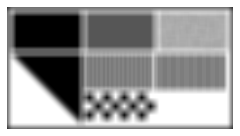

In [15]:
img_mean = mean_filter(img, 9)
plot_img_orig(img_mean)

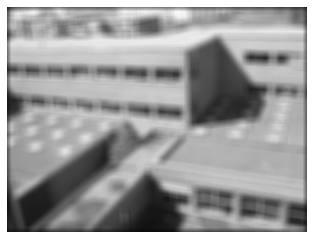

In [48]:
img_mean_cv = cv2.blur(img, ksize=(9,9))
plot_img_orig(img_mean)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 6.4</span> Arbitrary Filter Masks and Separable Filters

To be flexible, it should be possible to use arbitrary filter masks. The masks can then be specified by a Numpy <a href="https://numpy.org/doc/stable/reference/generated/numpy.array.html">`array` ↗</a>.

Implement the following tasks:
1. Write a function to filter an image by a given $m\times n$ mask (for odd $m, n$ and zero padding). You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.multiply.html">`multiply` ↗</a> from Numpy for element-wise matrix multiplication.
2. Create a Numpy <a href="https://numpy.org/doc/stable/reference/generated/numpy.array.html">`array` ↗</a> corresponding to a $9\times 9$ averaging mask and compare the filtering result with the previous task for the image *testpattern-512.png*.
3. Measure the computation time of the filtering process (you can use the function <a href="https://docs.python.org/3/library/time.html#time.time">`time.time()` ↗</a> for this).

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a>.

In [18]:
# write your code here

# filter given image with given m x n mask
def filter_image(img, mask):
    # compute offset / padding size
    m, n = mask.shape # size of the mask (m x n = rows x cols)
    if (m%2==0) or (n%2==0):
        print('returning main image')
        return img
    
    bh = int(m/2)
    bw = int(n/2)

    #img_pad = cv2.copyMakeBorder(img, bh, bh, bw, bw, cv2.BORDER_CONSTANT)
    rows, cols = img.shape
    res = np.zeros(shape=[rows, cols], dtype=np.float64)

    for row in range(bh, rows-bh):
        for col in range(bw, cols-bw):
            nbh = img[row-bh:row+bh+1, col-bw:col+bw+1]
            tmp = np.multiply(mask, nbh)
            tmp = np.sum(tmp)
            res[row, col] = tmp
            
    res = res/(m*n)
    
    res = res[bh:rows-bh, bw:cols-bw]
    return res
    
    # ...

In [19]:
img = np.array([[0,0,0,0,0], [0,1,2,1,0], [0,2,3,2,0], [0,1,2,1,0], [0,0,0,0,0]])
mask = np.array([[-1,0,1], [-2,0,2], [-1,0,1]])
print(img.size, mask.size)
filter_image(img, mask)


25 9


array([[ 0.77777778,  0.        , -0.77777778],
       [ 1.11111111,  0.        , -1.11111111],
       [ 0.77777778,  0.        , -0.77777778]])

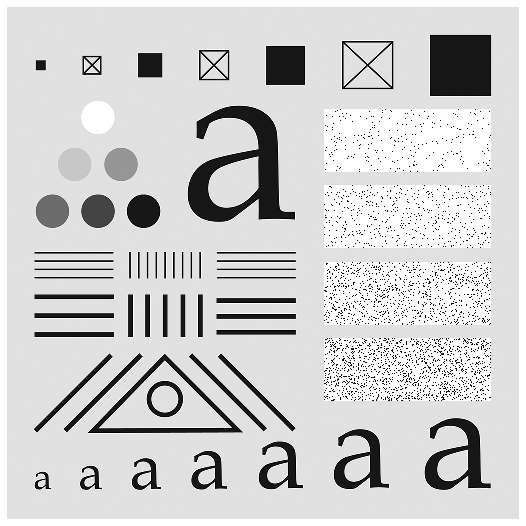

In [20]:
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

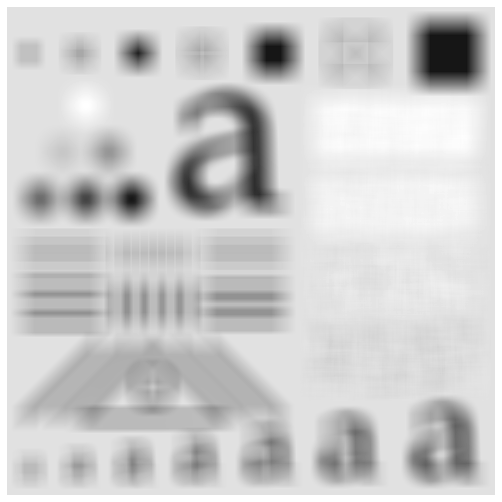

In [22]:
mask = np.ones((25,25))
masked = filter_image(img, mask)
plot_img_orig(masked)

#### <span style="color: RoyalBlue; font-weight: bold;">Task 6.5</span> Separable Filters

Implement / solve the following tasks:
1. Seperate the box filter from the previous task into two filters and again compare the filtering result.
2. Again measure the computation time of the filtering process (you can use the function <a href="https://docs.python.org/3/library/time.html#time.time">`time.time()` ↗</a> for this).
3. Analyze the number of operations required for filtering an $M \times N$ image using a $m\times n$ mask and for the case that the corresponding seperated filters are used. Compare the computation times for both cases. Do the seperate filters accelerate the filtering?

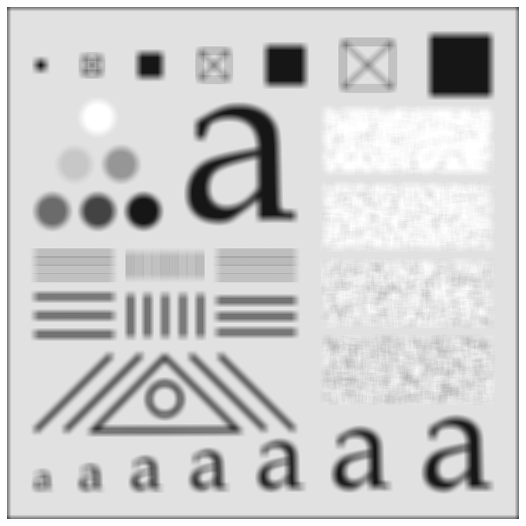

In [75]:
# write your code here
mask1 = np.ones((9,1))
mask2 = np.ones((1,9))

img = cv2.imread('images/testpattern-512.png', 0)

masked1 = filter_image(img, mask1)
masked2 = filter_image(masked1, mask2)
plot_img_orig(masked2)

In [2]:
np.sqrt(2) * np.sqrt(2)

2.0000000000000004

In [4]:
a1 = np.array([1,1,1])
a2 = np.array([1,1,1])
np.outer(1/np.sqrt(2)*a1, 1/np.sqrt(2)*a2)

array([[0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5]])

In [6]:
s1 = np.array([1,2,1])
s2 = np.array([-1,0,1])
np.outer(s1, s2)

array([[-1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [9]:
b1 = np.array([1,2,1])
b2 = np.array([1,2,1]) #3 6 3
np.outer(np.sqrt(3)*b1,np.sqrt(3)*b2)

array([[ 3.,  6.,  3.],
       [ 6., 12.,  6.],
       [ 3.,  6.,  3.]])